In [125]:
# importing library 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from kneed import KneeLocator
from sklearn.metrics import silhouette_score


In [40]:
df = pd.read_csv("smartcart_customers.csv")

df.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
1030,5204,1971,Graduation,Together,74538.0,0,0,29-06-2013,21,380,...,110,112,28,1,8,8,5,3,0,1
1057,8104,1951,PhD,Married,53312.0,0,0,09-08-2013,32,241,...,0,0,25,1,5,1,5,7,0,0
779,10736,1971,Graduation,Single,72258.0,0,1,12-09-2013,28,522,...,227,120,134,2,6,9,5,2,0,0
499,466,1944,Graduation,Married,65275.0,0,0,03-04-2013,9,388,...,91,14,21,1,4,3,13,2,0,0
461,7851,1949,Graduation,Widow,70165.0,0,0,22-09-2013,60,161,...,199,191,122,1,3,7,11,1,0,0


In [41]:
df.shape

(2240, 22)

In [42]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing


In [43]:
# handle missing value's by SimpleImputer

median_imputer = SimpleImputer(strategy="median")

df["Income"] = median_imputer.fit_transform(df[["Income"]])[:, 0]

df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [44]:
# feature engineering

# we have "Year_Birth" column that isn't much more meaningful but if we convert it into age of customer this will reflect more impact on our dataset

now = pd.Timestamp.now()

df["Age"] = now.year - df["Year_Birth"]
df = df.drop("Year_Birth", axis="columns")
df.sample()

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
317,9478,Graduation,Single,66503.0,1,0,14-08-2012,30,91,64,...,3,50,2,4,3,6,3,0,0,41


In [45]:
# from the Date of joining of customer. we have to calculate customer tenure day by today's date 

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
now = pd.Timestamp.now()


df["Customer_Tenure_days"] = (now - df["Dt_Customer"]).dt.days

# drop DT_customer
df = df.drop("Dt_Customer", axis="columns")


In [46]:
df.columns

Index(['ID', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_days'],
      dtype='object')

In [47]:
# multiple columns --> into 1
# 1. Total_Spending_On_Purchasing = (MntWines + MntFruits + MntMeatProducts + MntFishProducts + MntSweetProducts + MntGoldProds)
df["Total_Spending_On_Purchasing"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
df = df.drop(["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"], axis="columns")

# 2. Total_Child = (Kidhome + Teenhome)
df["Total_Child"] = df["Kidhome"] + df["Teenhome"] 
df = df.drop(["Kidhome", "Teenhome"], axis="columns")


In [ ]:
# customer id don't have any significance on data set so we will remove it

df = df.drop("ID", axis="columns")

In [49]:
df

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending_On_Purchasing,Total_Child
0,Graduation,Single,58138.0,58,3,8,10,4,7,0,1,69,5009,1617,0
1,Graduation,Single,46344.0,38,2,1,1,2,5,0,0,72,4459,27,2
2,Graduation,Together,71613.0,26,1,8,2,10,4,0,0,61,4658,776,0
3,Graduation,Together,26646.0,26,2,2,0,4,6,0,0,42,4485,53,1
4,PhD,Married,58293.0,94,5,5,3,6,5,0,0,45,4507,422,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduation,Married,61223.0,46,2,9,3,4,5,0,0,59,4727,1341,1
2236,PhD,Together,64014.0,56,7,8,2,5,7,0,0,80,4365,444,3
2237,Graduation,Divorced,56981.0,91,1,2,3,13,6,0,0,45,4501,1241,0
2238,Master,Together,69245.0,8,2,6,5,10,3,0,0,70,4502,843,1


In [50]:
df["Education"].value_counts()

# Graduation    1127 ---> Graduate
# PhD            486 --- 
#                       ---> PostGraduate
# Master         370 ---
# 2n Cycle       203 ---
#                       ---> UnderGraduate
# Basic           54 ---

df["Education"] = df["Education"].replace({
    "Basic": "UnderGraduate",
    "2n Cycle": "UnderGraduate",
    "Graduation": "Graduate",
    "Master": "PostGraduate",
    "PhD": "PostGraduate"
})

In [51]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [52]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

df = df.drop("Marital_Status", axis="columns")

In [53]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [54]:
df_cleaned = df

df.shape
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_days', 'Total_Spending_On_Purchasing', 'Total_Child',
       'Living_With'],
      dtype='object')

## Outlier detection

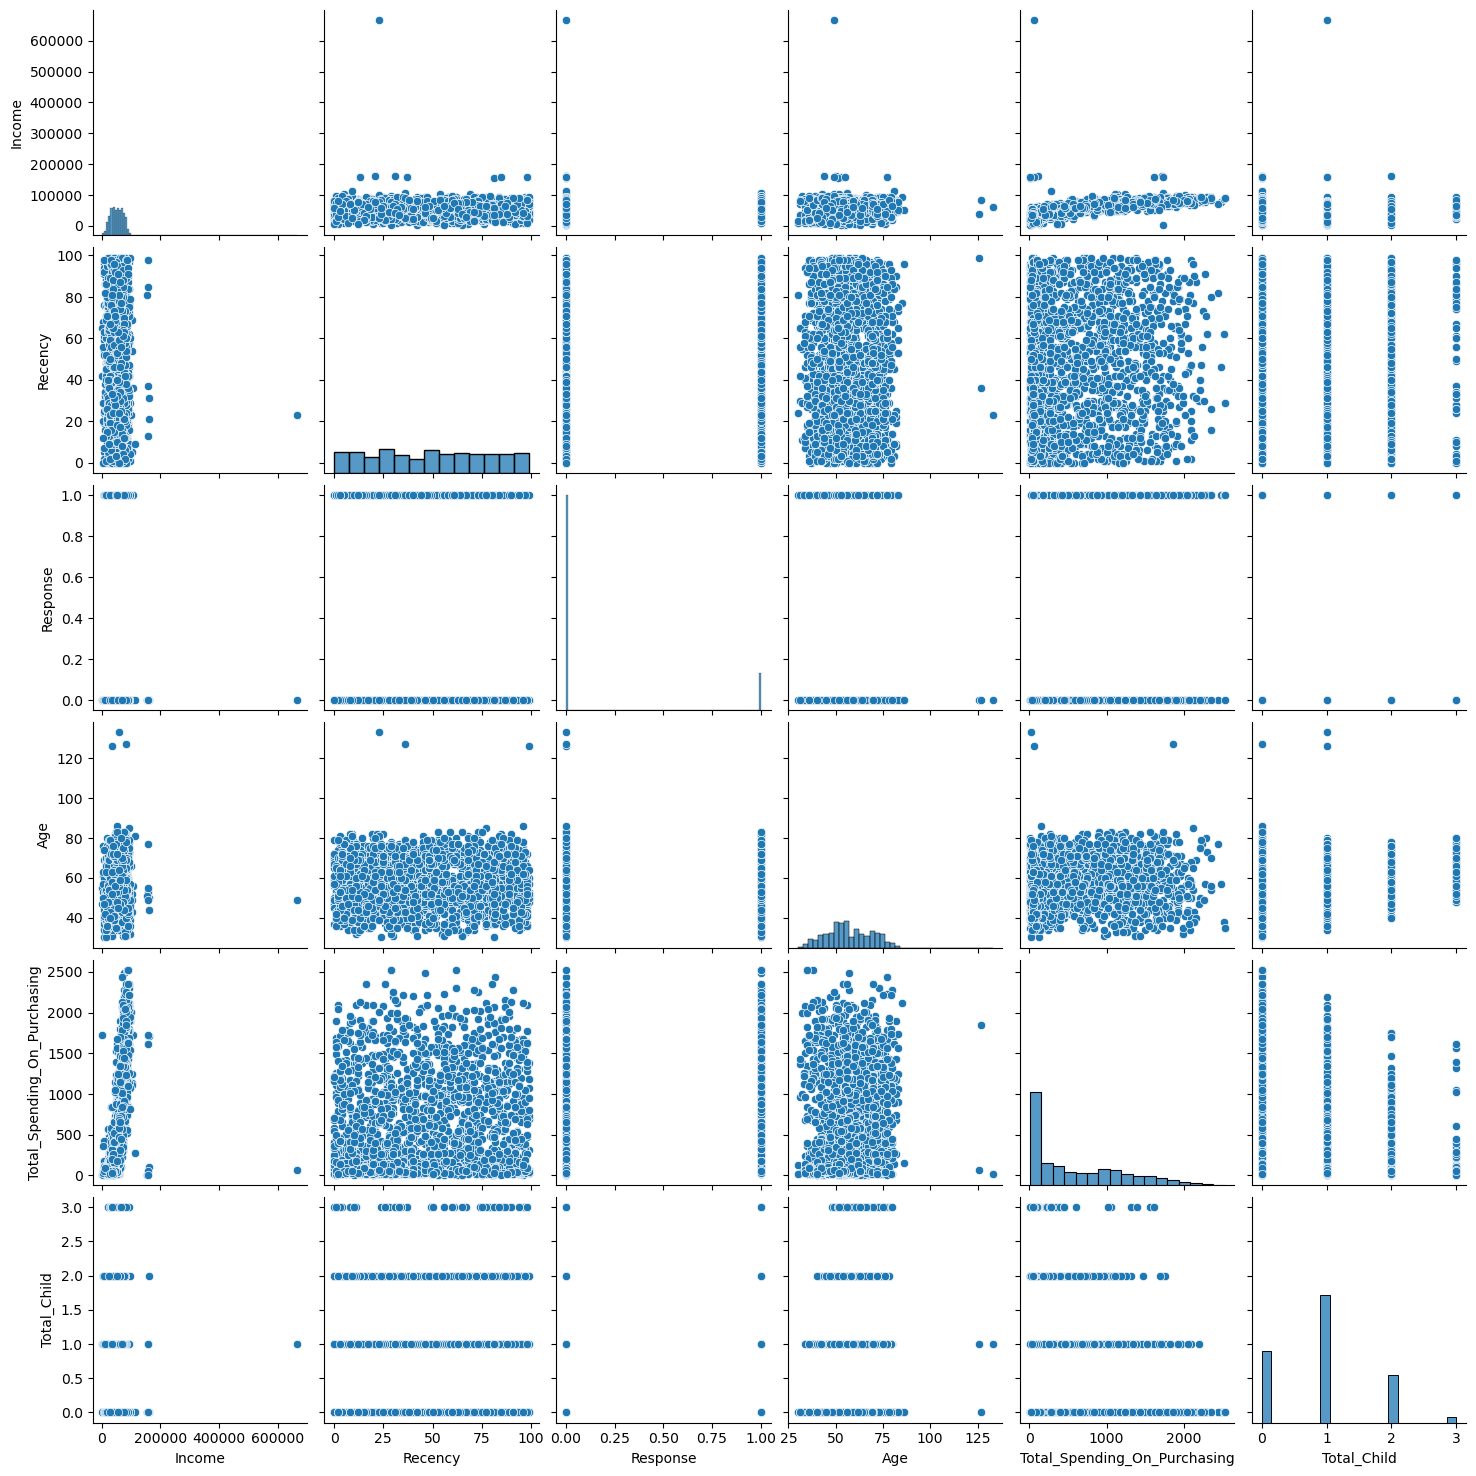

In [55]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending_On_Purchasing", "Total_Child"]

# Relative plot's of some feature:- pair plots

sns.pairplot(df_cleaned[cols])

* In the income data, we observed a customer with an income of ~600,000+ this acts as 'noise' in our dataset.
* in Age there are some people with age 120+

In [56]:
# removing outlier

print(f"Data size with oulier: {len(df_cleaned)}")

df_cleaned = df_cleaned[df_cleaned["Age"] < 90]
df_cleaned = df_cleaned[df_cleaned["Income"] < 600_000]

print(f"Data size without oulier: {len(df_cleaned)}")

Data size with oulier: 2240
Data size without oulier: 2236


In [57]:
# heatmap

corr = df_cleaned.corr(numeric_only=True)

In [58]:
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending_On_Purchasing,Total_Child
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


<Axes: >

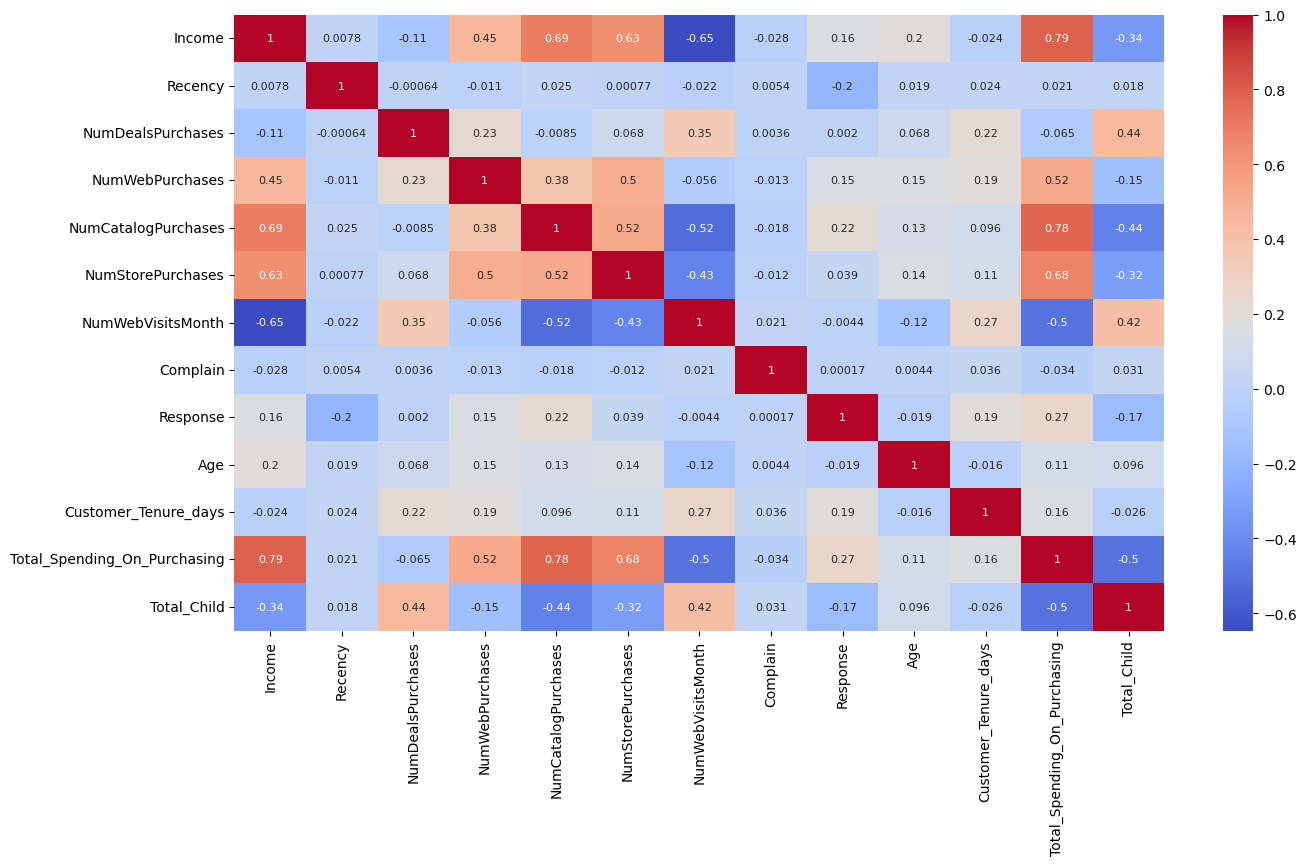

In [59]:
plt.figure(figsize=(15, 8))
sns.heatmap(corr, 
            annot=True, 
            cmap="coolwarm", 
            annot_kws={   
                "size": 8   # define size of number in heatmap
                }
            )

### insights from heatmap

* income show high +ve correlation with total spending (0.79)
* income high show customer will purchase catalog product (0.69)....
* high earner customer don't visit website (-0.65)
* number of catalog purchase inc total spending (0.78)

In [60]:
df_cleaned.shape
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_days', 'Total_Spending_On_Purchasing', 'Total_Child',
       'Living_With'],
      dtype='object')

## # feature Encoding

In [ ]:
ohe = OneHotEncoder() # we don't drop first columns in unsupervised ML

cat_cols = ["Education", "Living_With"]
encoded_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [62]:
encoded_df = pd.DataFrame(encoded_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [63]:
encoded_df

,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
2235,1.0,0.0,0.0,0.0,1.0
2236,0.0,1.0,0.0,0.0,1.0
2237,1.0,0.0,0.0,1.0,0.0
2238,0.0,1.0,0.0,0.0,1.0


In [65]:
df_encoded = pd.concat((df_cleaned.drop(columns=cat_cols), encoded_df), axis="columns")

In [149]:
df_encoded

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending_On_Purchasing,Total_Child,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,5009,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,4459,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,4658,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,4485,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,4507,422,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,4727,1341,1,1.0,0.0,0.0,0.0,1.0
2236,64014.0,56,7,8,2,5,7,0,0,80,4365,444,3,0.0,1.0,0.0,0.0,1.0
2237,56981.0,91,1,2,3,13,6,0,0,45,4501,1241,0,1.0,0.0,0.0,1.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,70,4502,843,1,0.0,1.0,0.0,0.0,1.0


## # Scaling our Data

In [76]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)

In [78]:
X_scaled = pd.DataFrame(X_scaled, columns=df_encoded.columns)

In [79]:
X_scaled

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending_On_Purchasing,Total_Child,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner
0,0.288947,0.306856,0.348738,1.407639,2.509801,-0.552429,0.692865,-0.095001,2.386338,1.016868,1.529793,1.680176,-1.264308,0.992870,-0.786840,-0.35878,1.347635,-1.347635
1,-0.262003,-0.383971,-0.168700,-1.110921,-0.568970,-1.167738,-0.131421,-0.095001,-0.419052,1.273264,-1.191143,-0.962202,1.395139,0.992870,-0.786840,-0.35878,1.347635,-1.347635
2,0.918423,-0.798467,-0.686137,1.407639,-0.226884,1.293496,-0.543564,-0.095001,-0.419052,0.333146,-0.206659,0.282541,-1.264308,0.992870,-0.786840,-0.35878,-0.742041,0.742041
3,-1.182183,-0.798467,-0.168700,-0.751127,-0.911056,-0.552429,0.280722,-0.095001,-0.419052,-1.290693,-1.062517,-0.918994,0.065416,0.992870,-0.786840,-0.35878,-0.742041,0.742041
4,0.296187,1.550344,1.383614,0.328256,0.115201,0.062879,-0.131421,-0.095001,-0.419052,-1.034298,-0.953679,-0.305762,0.065416,-1.007181,1.270907,-0.35878,-0.742041,0.742041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2231,0.433060,-0.107640,-0.168700,1.767433,0.115201,-0.552429,-0.131421,-0.095001,-0.419052,0.162216,0.134695,1.221499,0.065416,0.992870,-0.786840,-0.35878,-0.742041,0.742041
2232,0.563440,0.237773,2.418490,1.407639,-0.226884,-0.244775,0.692865,-0.095001,-0.419052,1.956986,-1.656175,-0.269201,2.724862,-1.007181,1.270907,-0.35878,-0.742041,0.742041
2233,0.234898,1.446720,-0.686137,-0.751127,0.115201,2.216459,0.280722,-0.095001,-0.419052,-1.034298,-0.983362,1.055312,-1.264308,0.992870,-0.786840,-0.35878,1.347635,-1.347635
2234,0.807803,-1.420212,-0.168700,0.688050,0.799373,1.293496,-0.955707,-0.095001,-0.419052,1.102333,-0.978415,0.393886,0.065416,-1.007181,1.270907,-0.35878,-0.742041,0.742041


## # Visualize the Data

In [80]:
X_scaled.shape

(2236, 18)

In [ ]:
# 2D visualization

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

<Axes: >

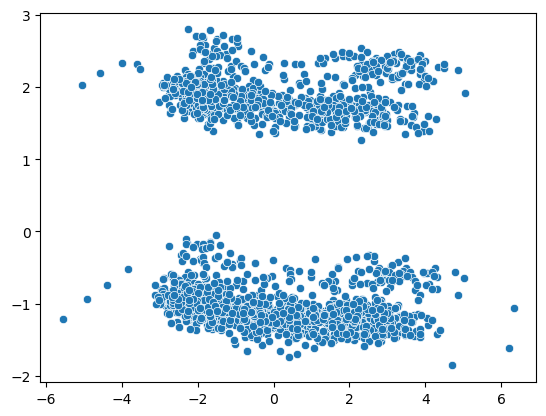

In [82]:
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1])

In [ ]:
pca.explained_variance_ratio_  # it capture only ~34.4% variance that isn't sufficient for us majority information become lost we may increase dimension of our PCA data

array([0.23163158, 0.11385454])

In [ ]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_) 

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)

# we can see as we increase n_dimension variance is increase 

[0.23163158 0.11385454 0.10405815]
[0.23163158 0.11385454 0.10405815 0.09912103]
[0.23163158 0.11385454 0.10405815 0.09912103 0.07729999]


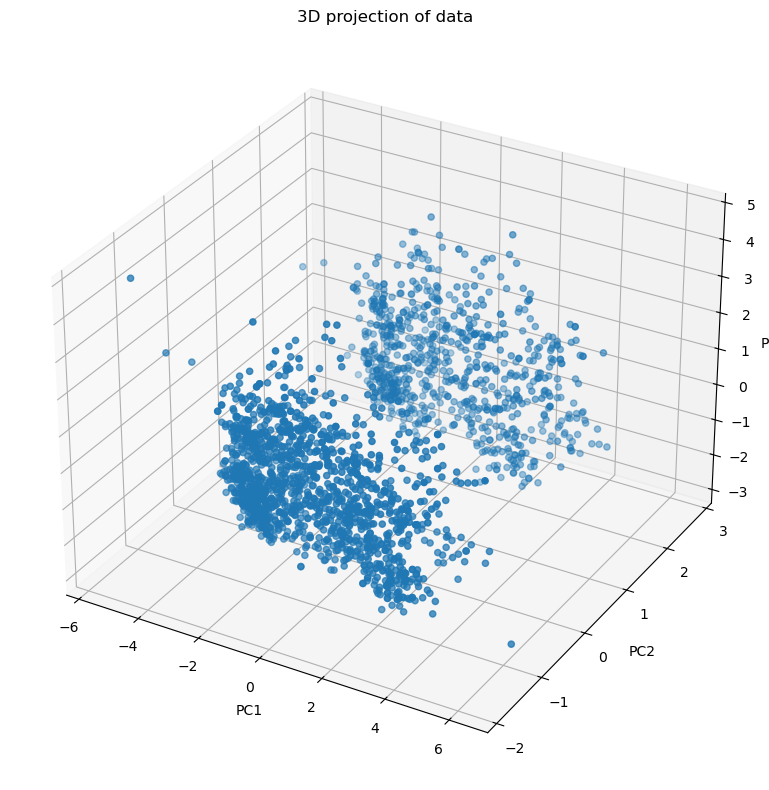

In [105]:
# let visualize in 3D 

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D projection of data")

plt.tight_layout()

## # Analyze K value

### 1. Elbow Method

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)

    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

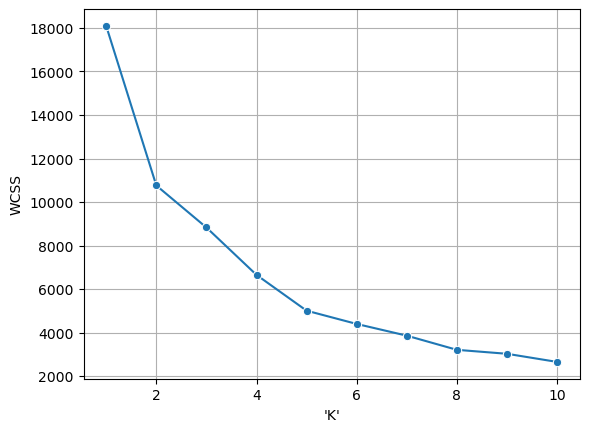

In [117]:
sns.lineplot(x=range(1,11), y=wcss, marker="o")
plt.grid()
plt.xlabel("\'K\'")
plt.ylabel("WCSS")

In [114]:
# By KneeLocator

knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")

print(f"Optimal value of K = {knee.knee}")

Optimal value of K = 4


### 2. Silhouette Score

Text(0, 0.5, 'silhouette_score')

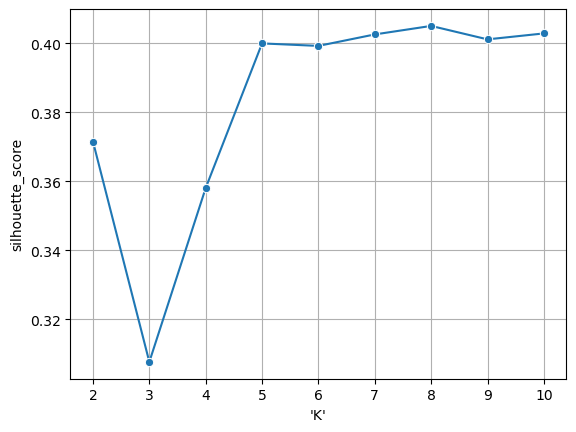

In [121]:
ss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)

    ss.append(silhouette_score(X_pca, labels))

sns.lineplot(x=range(2, 11), y=ss, marker="o")
plt.grid()
plt.xlabel("\'K\'")
plt.ylabel("silhouette_score")

* We don't always select the maximum value of the Silhouette score, we choose a value close to the intersection point of both the Elbow and Silhouette graphs

Text(0, 0.5, 'Silhouette Score')

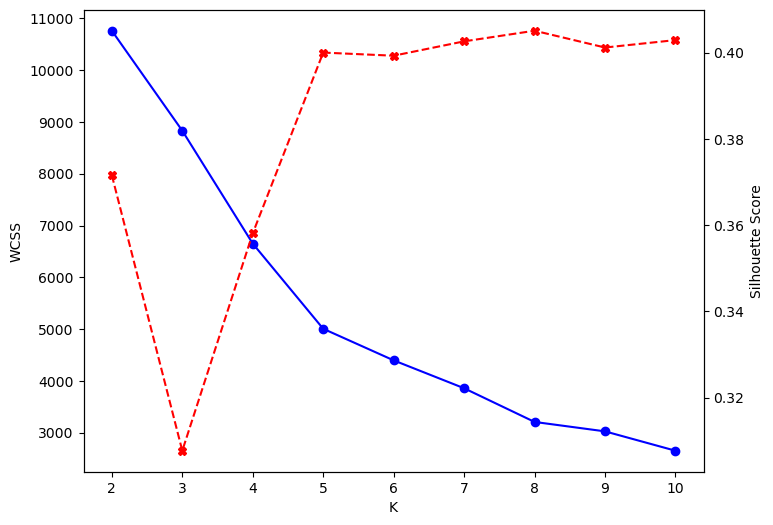

In [122]:
# combined graph

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[1: (len(k_range)+1)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, ss, marker="X", color="red", linestyle="--")
ax2.set_ylabel("Silhouette Score")

## Implement clustering Algorithm

### 1. KMeans

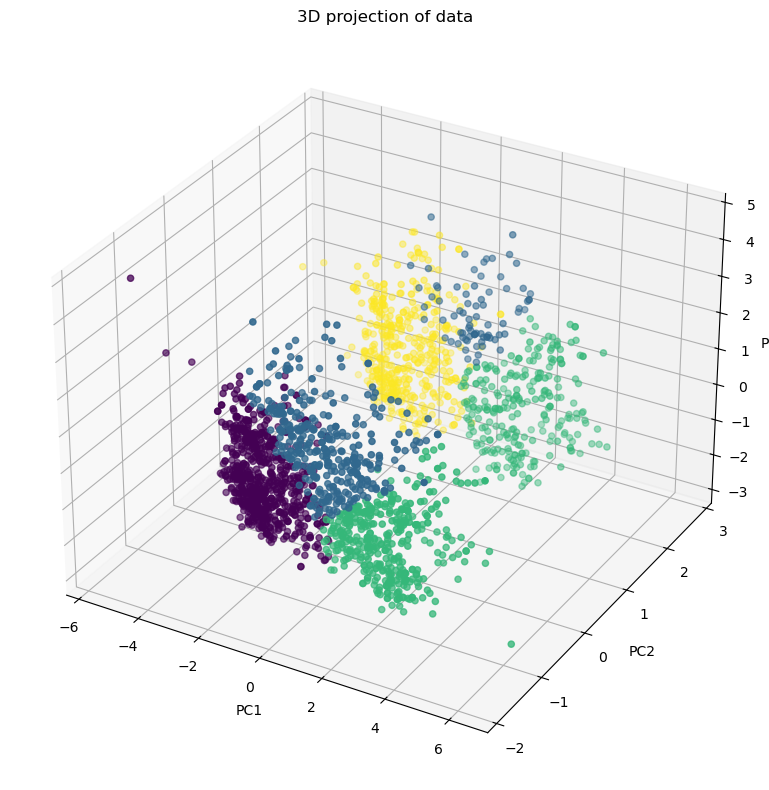

In [127]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

# plot the cluster how they look like

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=kmeans_labels)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D projection of data")

plt.tight_layout()

### 2. Agglomerative Clustering


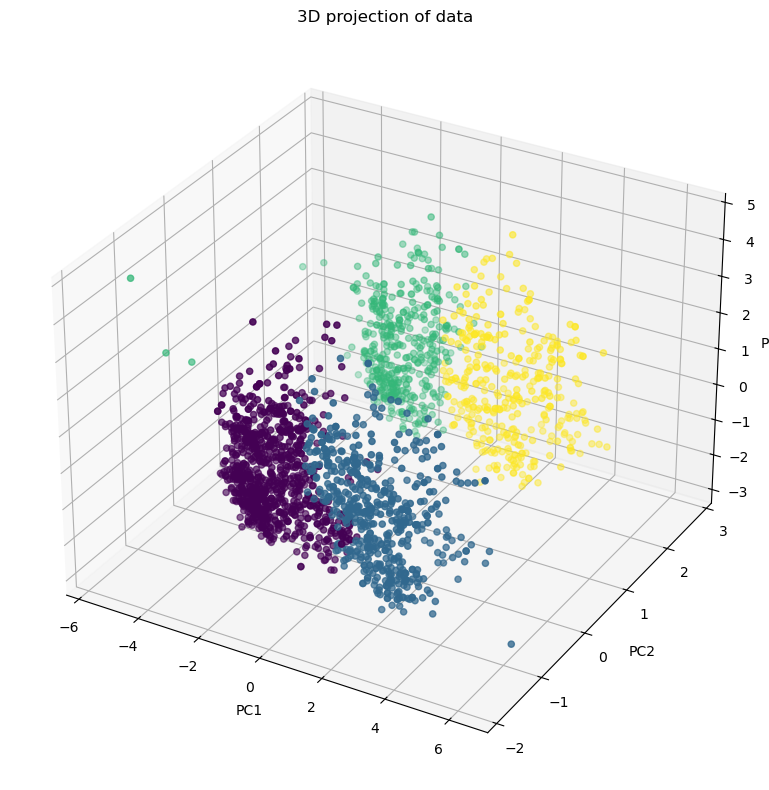

In [130]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
agg_labels = agg_clf.fit_predict(X_pca)

# plot the cluster how they look like

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=agg_labels)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D projection of data")

plt.tight_layout()

* we can see visually that agglomerative clustering perform better than KMeans so let's go with agglomerative labels

## # Characterization of Clustering


In [150]:
df_encoded["cluster"] = agg_labels

In [151]:
df_encoded

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending_On_Purchasing,Total_Child,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,5009,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,4459,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,4658,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,4485,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,4507,422,1,0.0,1.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,4727,1341,1,1.0,0.0,0.0,0.0,1.0,0
2236,64014.0,56,7,8,2,5,7,0,0,80,4365,444,3,0.0,1.0,0.0,0.0,1.0,0
2237,56981.0,91,1,2,3,13,6,0,0,45,4501,1241,0,1.0,0.0,0.0,1.0,0.0,3
2238,69245.0,8,2,6,5,10,3,0,0,70,4502,843,1,0.0,1.0,0.0,0.0,1.0,1


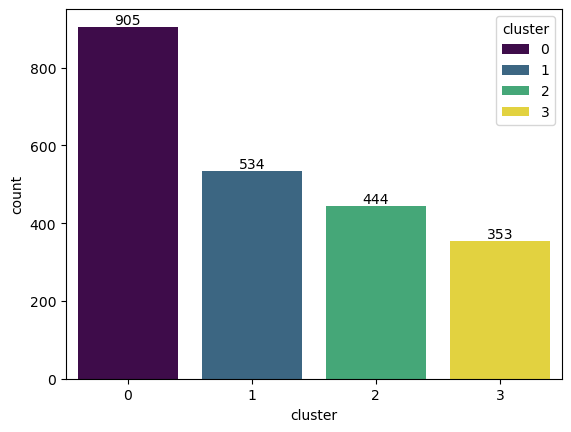

In [152]:
ax = sns.countplot(x=df_encoded["cluster"], hue=df_encoded["cluster"], palette="viridis")
for i in range(4):
    ax.bar_label(ax.containers[i])

<Axes: xlabel='Total_Spending_On_Purchasing', ylabel='Income'>

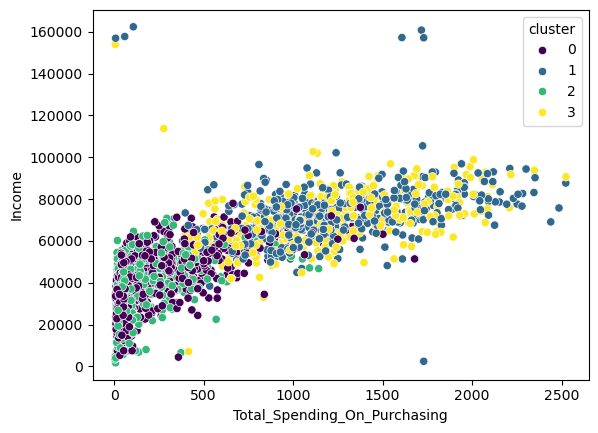

In [153]:
# for Income and spending pattern

sns.scatterplot(x=df_encoded["Total_Spending_On_Purchasing"], y=df_encoded["Income"], hue=df_encoded["cluster"], palette="viridis")

#### Key Insight's

* for "0" label cluster: low-moderate Income level customer with low-moderate spending
* for "1" label cluster: moderate-high Income level customer with moderate-high spending
* for "2" label cluster: low-moderate Income level customer with low spending
* for "3" label cluster: moderate Income level customer with moderate-high spending

* cluster "1", "3" spending are high compare to "0", "2" and same scenario with income

### Cluster Summary 
* all information for all respective cluster 


In [154]:
cluster_summary = df_encoded.groupby("cluster").mean()

In [ ]:
cluster_summary 

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending_On_Purchasing,Total_Child,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner
cluster,,,,,,,,,,,,,,,,,,
0,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,4688.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,4715.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,4684.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,4722.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000


## # for more information checkout README.md :)